## improved viz for report

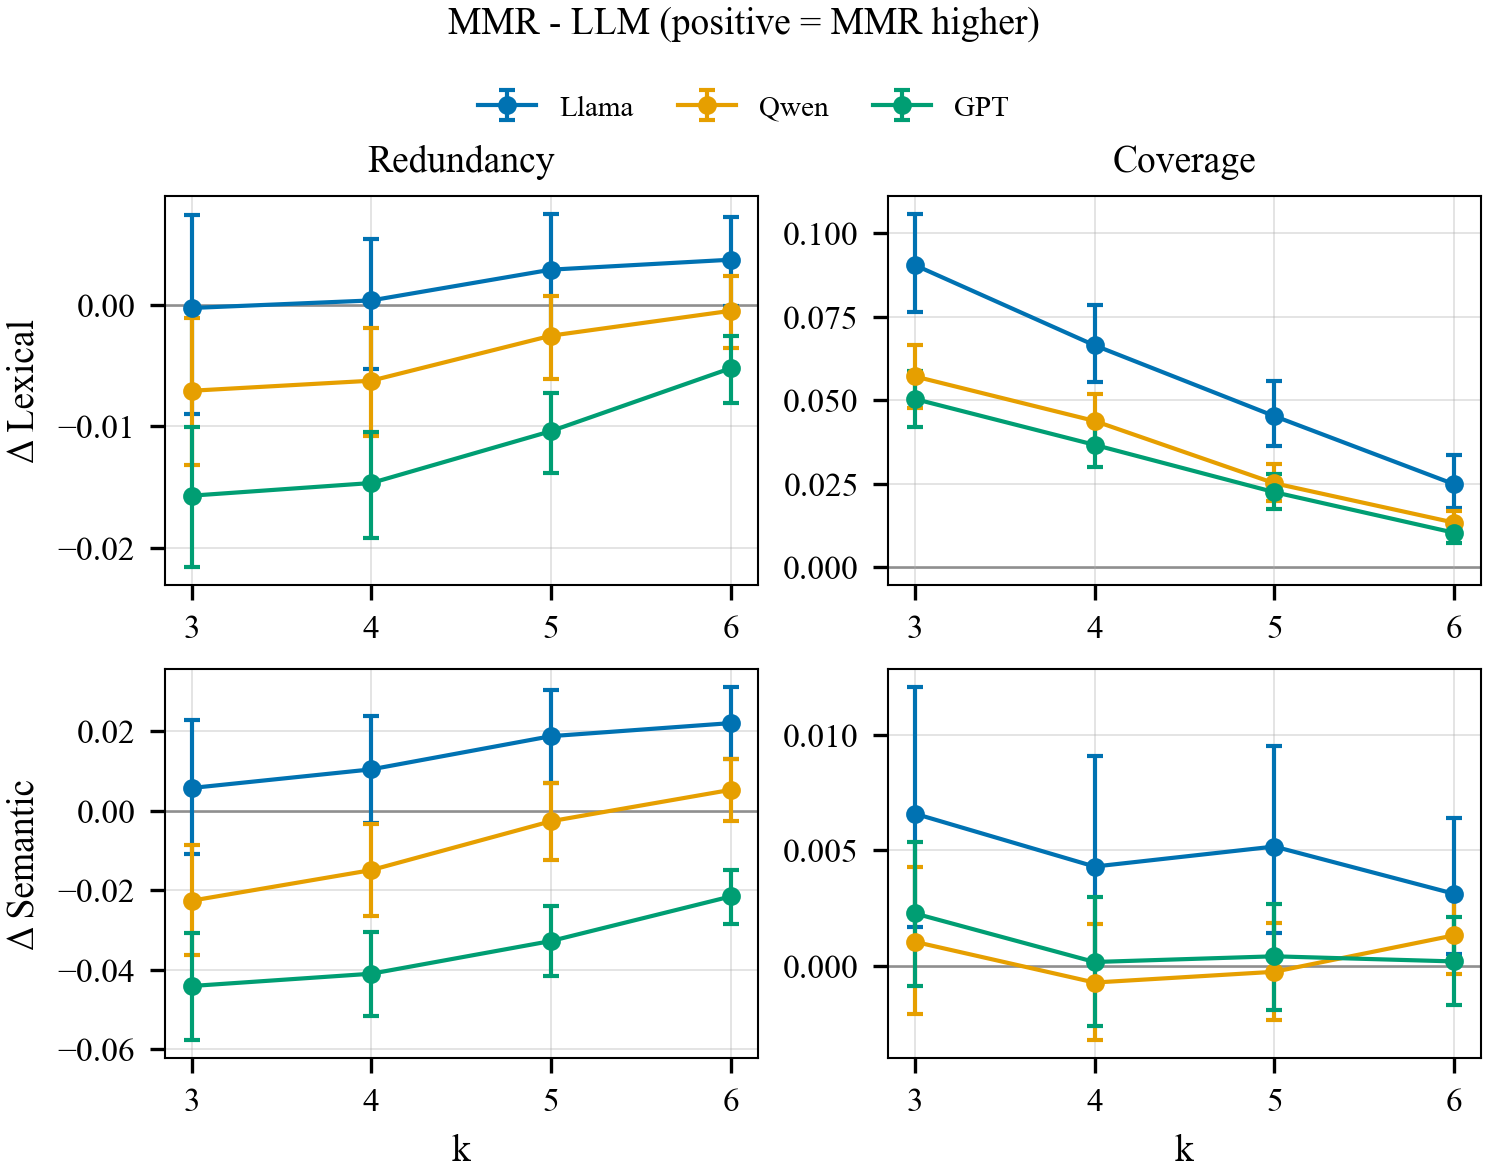

In [ ]:
import os
import re
import json
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import Path

RUN_ROOT = Path.cwd() / "runs_fixed_pool_rerank"


PREP_ROWS_PATH = os.path.join(RUN_ROOT, "prep_20260201_185037\prep_rows.jsonl") 

RUNS = {
    "Llama": os.path.join(RUN_ROOT, "exp1_llama_20260131_140548"),
    "Qwen": os.path.join(RUN_ROOT, "exp1_qwen_20260131_143032"),
    "GPT": os.path.join(RUN_ROOT, "exp1_gpt_20260131_154255"),
}

KEEP_LIST = [3, 4, 5, 6]
MODEL_ORDER = ["Llama", "Qwen", "GPT"]
METHODS = ["bm25", "mmr", "llm", "rand"]
METHOD_PREFIX = {"BM25": "bm25", "MMR": "mmr", "LLM": "llm", "Random": "rand"}
COMPARISONS = [("MMR", "LLM"), ("BM25", "LLM"), ("LLM", "Random")]


def read_jsonl(path):
    out = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                out.append(json.loads(line))
    return out


def paired_bootstrap_ci(a, b, n_boot=10000, seed=12345, alpha=0.05):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    n = len(a)
    rng = np.random.default_rng(seed)
    obs = float(np.mean(a - b))
    idx = rng.integers(0, n, size=(n_boot, n))
    diffs = (a[idx] - b[idx]).mean(axis=1)
    lo, hi = np.quantile(diffs, [alpha / 2, 1 - alpha / 2])
    return obs, float(lo), float(hi)


def get_metric_array(rows, method_label, metric_key):
    prefix = METHOD_PREFIX[method_label]
    col = f"{prefix}_{metric_key}"
    return np.array([r[col] for r in rows], dtype=float)


def split_sents(text):
    t = re.sub(r"\s+", " ", (text or "")).strip()
    if not t:
        return []
    sents = re.split(r"(?<=[\.\!\?])\s+", t)
    return [s.strip() for s in sents if s.strip()]


def view_doc(d, n=600):
    return re.sub(r"\s+", " ", d).strip()[:n]


def semred(doc_emb):
    n = int(doc_emb.shape[0])
    if n < 2:
        return 0.0
    sims = doc_emb @ doc_emb.T
    iu = np.triu_indices(n, k=1)
    return float(np.mean(sims[iu]))


def semcov(summary_sent_emb, doc_emb):
    if summary_sent_emb is None or summary_sent_emb.shape[0] == 0 or doc_emb.shape[0] == 0:
        return 0.0
    sims = summary_sent_emb @ doc_emb.T
    return float(np.mean(np.max(sims, axis=1)))


prep_rows = read_jsonl(PREP_ROWS_PATH)

flat_by_run = {}
for name, run_dir in RUNS.items():
    flat_by_run[name] = read_jsonl(os.path.join(run_dir, "results_by_keep_flat.jsonl"))

LEX_BOOT = {}
for name in MODEL_ORDER:
    flat = flat_by_run[name]
    LEX_BOOT[name] = {}
    for k in KEEP_LIST:
        rows = [r for r in flat if int(r["keep"]) == k]
        LEX_BOOT[name][f"K{k}"] = {}
        for metric in ["red_cont", "cov_cont", "sum_rec"]:
            LEX_BOOT[name][f"K{k}"][metric] = {}
            for A, B in COMPARISONS:
                a = get_metric_array(rows, A, metric)
                b = get_metric_array(rows, B, metric)
                obs, lo, hi = paired_bootstrap_ci(a, b)
                LEX_BOOT[name][f"K{k}"][metric][f"{A}-{B}"] = {"mean_delta": obs, "lo": lo, "hi": hi}

st_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

SEM_BOOT = {}
for name in MODEL_ORDER:
    flat = flat_by_run[name]
    idxs = sorted({int(r["idx"]) for r in flat})
    
    idx_to_doc_emb = {}
    idx_to_sum_emb = {}
    
    for idx in idxs:
        ex = prep_rows[idx]
        docs = [view_doc(c) for c in ex["candidates_8"]]
        doc_emb = st_model.encode(docs, normalize_embeddings=True)
        sents = split_sents(ex.get("summary", ""))
        if sents:
            sum_emb = st_model.encode(sents, normalize_embeddings=True)
        else:
            sum_emb = np.zeros((0, doc_emb.shape[1]), dtype=np.float32)
        idx_to_doc_emb[idx] = doc_emb
        idx_to_sum_emb[idx] = sum_emb
    
    semantic_rows = []
    for r in flat:
        rr = dict(r)
        idx = int(rr["idx"])
        doc_all = idx_to_doc_emb[idx]
        sum_emb = idx_to_sum_emb[idx]
        for m in METHODS:
            topk = rr[f"{m}_topk"]
            emb = doc_all[topk]
            rr[f"{m}_semred"] = semred(emb)
            rr[f"{m}_semcov"] = semcov(sum_emb, emb)
        semantic_rows.append(rr)
    
    SEM_BOOT[name] = {}
    for k in KEEP_LIST:
        rows = [r for r in semantic_rows if int(r["keep"]) == k]
        SEM_BOOT[name][f"K{k}"] = {}
        for metric in ["semred", "semcov"]:
            SEM_BOOT[name][f"K{k}"][metric] = {}
            for A, B in COMPARISONS:
                a = get_metric_array(rows, A, metric)
                b = get_metric_array(rows, B, metric)
                obs, lo, hi = paired_bootstrap_ci(a, b)
                SEM_BOOT[name][f"K{k}"][metric][f"{A}-{B}"] = {"mean_delta": obs, "lo": lo, "hi": hi}

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "axes.linewidth": 0.5,
    "grid.linewidth": 0.4,
    "lines.linewidth": 1.0,
    "lines.markersize": 3.5,
    "errorbar.capsize": 2,
})

COLORS = {"Llama": "#0072B2", "Qwen": "#E69F00", "GPT": "#009E73"}
COMP = "MMR-LLM"

fig, axes = plt.subplots(2, 2, figsize=(5.0, 3.5), constrained_layout=True)

metrics_grid = [
    [("red_cont", LEX_BOOT), ("cov_cont", LEX_BOOT)],
    [("semred", SEM_BOOT), ("semcov", SEM_BOOT)],
]
row_labels = ["Lexical", "Semantic"]
col_labels = ["Redundancy", "Coverage"]

for row in range(2):
    for col in range(2):
        ax = axes[row, col]
        ax.axhline(0, color="gray", linewidth=0.6, linestyle="-", zorder=1)
        metric_key, data_source = metrics_grid[row][col]
        for name in MODEL_ORDER:
            ys = [data_source[name][f"K{k}"][metric_key][COMP]["mean_delta"] for k in KEEP_LIST]
            los = [data_source[name][f"K{k}"][metric_key][COMP]["lo"] for k in KEEP_LIST]
            his = [data_source[name][f"K{k}"][metric_key][COMP]["hi"] for k in KEEP_LIST]
            yerr = [np.array(ys) - np.array(los), np.array(his) - np.array(ys)]
            ax.errorbar(
                KEEP_LIST, ys, yerr=yerr, marker="o", color=COLORS[name],
                label=name if (row == 0 and col == 0) else None, zorder=3,
            )
        ax.set_xticks(KEEP_LIST)
        ax.grid(True, alpha=0.4, linewidth=0.4, zorder=0)
        if row == 0:
            ax.set_title(col_labels[col], fontweight="medium")
        if col == 0:
            ax.set_ylabel(f"Δ {row_labels[row]}")
        if row == 1:
            ax.set_xlabel("k")

fig.legend(loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.06), columnspacing=1.5)
fig.suptitle("MMR - LLM (positive = MMR higher)", fontsize=9, y=1.12, fontweight="medium")

plt.savefig("fig_metrics_comparison.pdf")
plt.savefig("fig_metrics_comparison.png", dpi=300)
plt.show()